# IMDB Movie Review Sentiment Analysis

This notebook analyzes audience sentiment from the IMDB movie review dataset using NLP techniques. We will:

1. Explore the dataset
2. Clean and preprocess review text
3. Analyze word patterns for positive vs. negative reviews
4. Build a machine learning model (TF-IDF + classifiers) to predict sentiment
5. Evaluate model performance and summarize overall audience sentiment

## 1. Import Libraries

In [3]:
import pandas as pd
import numpy as np
import re
import string
from collections import Counter

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)


## 2. Load the Dataset

In [4]:
df = pd.read_csv(r"C:\Users\satis\Downloads\archive (2)\IMDB Dataset.csv")   # update path if needed
print("Shape:", df.shape)
df.head()


Shape: (50000, 2)


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [5]:
df.info()
print("\nMissing values:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB

Missing values:
 review       0
sentiment    0
dtype: int64

Duplicate rows: 418


In [6]:
# Drop duplicates if any
df = df.drop_duplicates().reset_index(drop=True)
print("Shape after removing duplicates:", df.shape)


Shape after removing duplicates: (49582, 2)


## 3. Explore Audience Sentiment Distribution

The dataset already contains a `sentiment` label (positive/negative) provided by reviewers — this is a direct measure of audience sentiment.

sentiment
positive    24884
negative    24698
Name: count, dtype: int64


C:\Users\satis\AppData\Local\Temp\ipykernel_4808\354205955.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sentiment', data=df, ax=axes[0], palette='Set2')


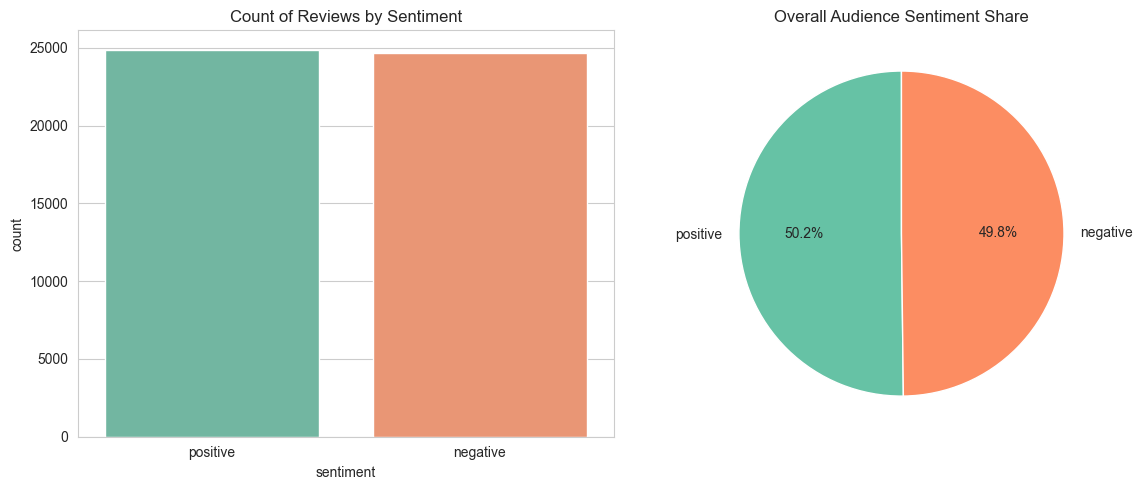

In [7]:
sentiment_counts = df['sentiment'].value_counts()
print(sentiment_counts)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(x='sentiment', data=df, ax=axes[0], palette='Set2')
axes[0].set_title('Count of Reviews by Sentiment')

axes[1].pie(sentiment_counts.values, labels=sentiment_counts.index,
            autopct='%1.1f%%', colors=sns.color_palette('Set2'), startangle=90)
axes[1].set_title('Overall Audience Sentiment Share')

plt.tight_layout()
plt.show()


## 4. Text Cleaning & Preprocessing

We remove HTML tags, punctuation, numbers, and normalize case. This prepares raw reviews for NLP analysis.

In [8]:
def clean_text(text):
    text = re.sub(r'<.*?>', ' ', text)               # remove HTML tags (e.g. <br />)
    text = re.sub(r'http\S+|www\S+', ' ', text)      # remove URLs
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)          # keep only letters
    text = text.lower()                               # lowercase
    text = re.sub(r'\s+', ' ', text).strip()          # collapse whitespace
    return text

df['clean_review'] = df['review'].apply(clean_text)
df[['review', 'clean_review']].head(3)


,review,clean_review
0,One of the other reviewers has mentioned that ...,one of the other reviewers has mentioned that ...
1,A wonderful little production. <br /><br />The...,a wonderful little production the filming tech...
2,I thought this was a wonderful way to spend ti...,i thought this was a wonderful way to spend ti...


In [9]:
# Add review length features
df['review_length'] = df['review'].apply(len)
df['word_count'] = df['clean_review'].apply(lambda x: len(x.split()))

df[['review_length', 'word_count']].describe()


,review_length,word_count
count,49582.000000,49582.000000
mean,1310.568230,234.362410
std,990.762238,173.698094
min,32.000000,6.000000
25%,699.000000,128.000000
50%,971.000000,176.000000
75%,1592.000000,284.000000
max,13704.000000,2494.000000


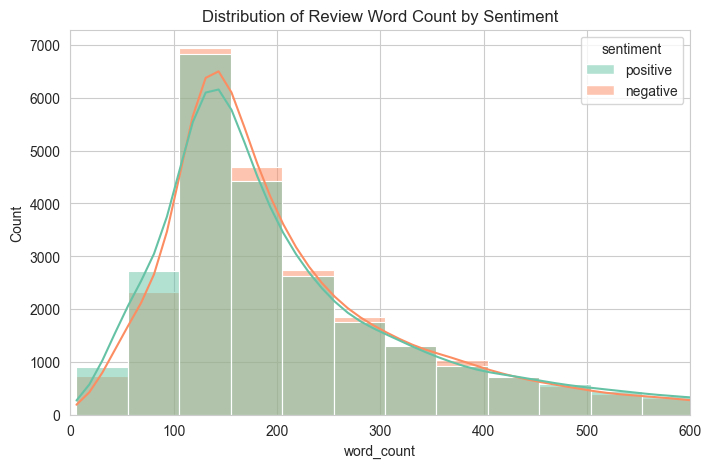

In [10]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='word_count', hue='sentiment', bins=50, kde=True, palette='Set2')
plt.title('Distribution of Review Word Count by Sentiment')
plt.xlim(0, 600)
plt.show()


## 5. Most Frequent Words by Sentiment

Using basic word frequency counts (with English stop words removed) to see what audiences talk about most in positive vs. negative reviews.

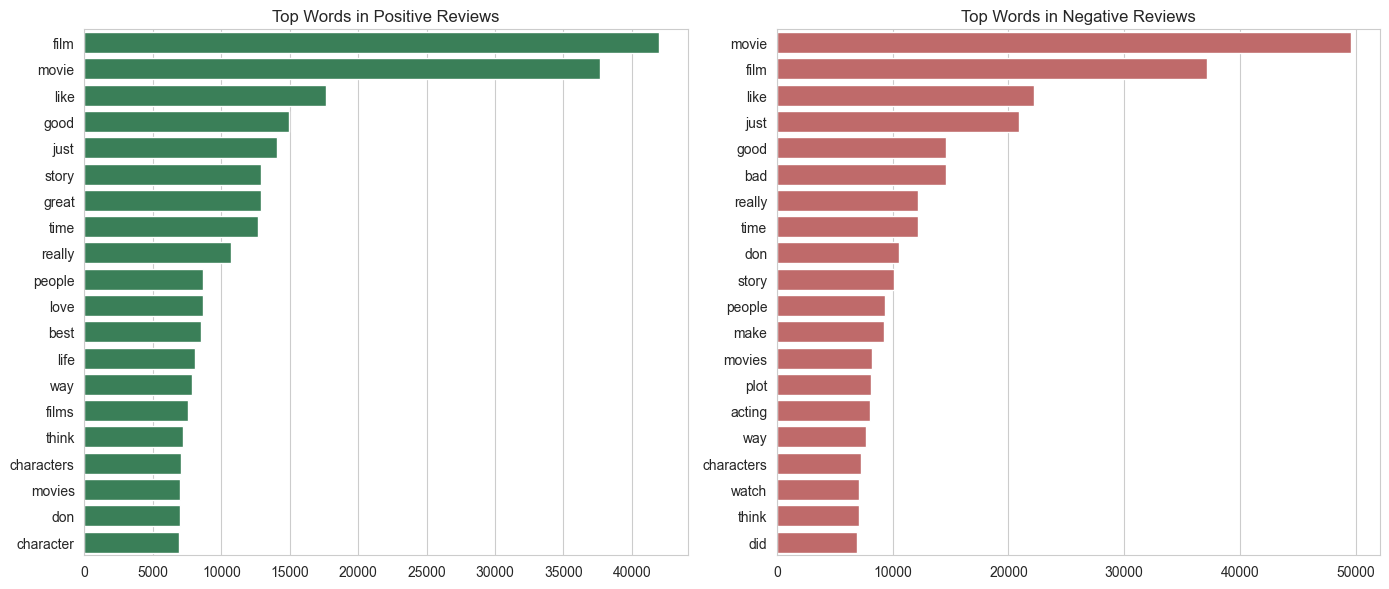

In [11]:
def top_words(text_series, n=20):
    words = ' '.join(text_series).split()
    words = [w for w in words if w not in ENGLISH_STOP_WORDS and len(w) > 2]
    return Counter(words).most_common(n)

pos_top = top_words(df.loc[df['sentiment'] == 'positive', 'clean_review'])
neg_top = top_words(df.loc[df['sentiment'] == 'negative', 'clean_review'])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.barplot(x=[c for _, c in pos_top], y=[w for w, _ in pos_top], ax=axes[0], color='seagreen')
axes[0].set_title('Top Words in Positive Reviews')

sns.barplot(x=[c for _, c in neg_top], y=[w for w, _ in neg_top], ax=axes[1], color='indianred')
axes[1].set_title('Top Words in Negative Reviews')

plt.tight_layout()
plt.show()


## 6. Feature Extraction with TF-IDF

Convert cleaned text into numerical features using TF-IDF (Term Frequency–Inverse Document Frequency), which weighs words by how distinctive they are to a review.

In [12]:
X = df['clean_review']
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

tfidf = TfidfVectorizer(max_features=10000, stop_words='english', ngram_range=(1, 2))
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Train shape:", X_train_tfidf.shape)
print("Test shape:", X_test_tfidf.shape)


Train shape: (39665, 10000)
Test shape: (9917, 10000)


## 7. Train Sentiment Classification Models

We train two common NLP baseline models: Logistic Regression and Multinomial Naive Bayes, then compare their performance.

In [14]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Multinomial Naive Bayes": MultinomialNB()
}

results = {}

for name, model in models.items():
    model.fit(X_train_tfidf, y_train)
    preds = model.predict(X_test_tfidf)
    acc = accuracy_score(y_test, preds)
    results[name] = (model, preds, acc)
    print(f"{name} Accuracy: {acc:.4f}")


Logistic Regression Accuracy: 0.8918
Multinomial Naive Bayes Accuracy: 0.8633


## 8. Evaluate the Best Model

In [15]:
best_name = max(results, key=lambda k: results[k][2])
best_model, best_preds, best_acc = results[best_name]
print(f"Best model: {best_name} (Accuracy: {best_acc:.4f})\n")

print(classification_report(y_test, best_preds))


Best model: Logistic Regression (Accuracy: 0.8918)

              precision    recall  f1-score   support

    negative       0.90      0.88      0.89      4940
    positive       0.88      0.91      0.89      4977

    accuracy                           0.89      9917
   macro avg       0.89      0.89      0.89      9917
weighted avg       0.89      0.89      0.89      9917



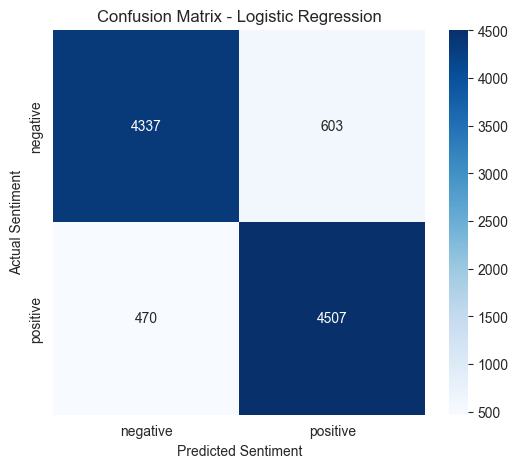

In [16]:
cm = confusion_matrix(y_test, best_preds, labels=best_model.classes_)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=best_model.classes_, yticklabels=best_model.classes_)
plt.xlabel('Predicted Sentiment')
plt.ylabel('Actual Sentiment')
plt.title(f'Confusion Matrix - {best_name}')
plt.show()


## 9. Most Influential Words (Model Insights)

For Logistic Regression, we can inspect which words push predictions toward positive or negative sentiment.

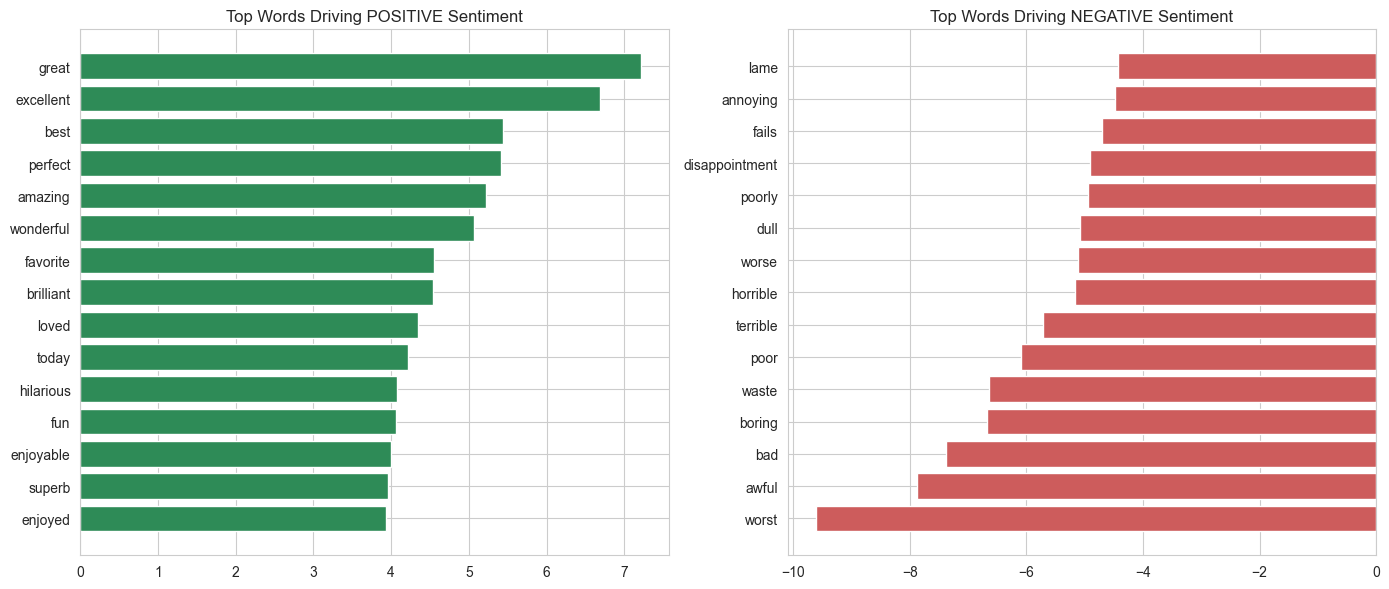

In [17]:
if isinstance(best_model, LogisticRegression):
    feature_names = np.array(tfidf.get_feature_names_out())
    coefs = best_model.coef_[0]

    top_pos_idx = np.argsort(coefs)[-15:]
    top_neg_idx = np.argsort(coefs)[:15]

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    axes[0].barh(feature_names[top_pos_idx], coefs[top_pos_idx], color='seagreen')
    axes[0].set_title('Top Words Driving POSITIVE Sentiment')

    axes[1].barh(feature_names[top_neg_idx], coefs[top_neg_idx], color='indianred')
    axes[1].set_title('Top Words Driving NEGATIVE Sentiment')

    plt.tight_layout()
    plt.show()
else:
    print("Feature importance plot shown only for Logistic Regression.")


## 10. Predict Sentiment on New/Custom Reviews

Use the trained model to classify sentiment of any new movie review text.

In [18]:
def predict_sentiment(text, model=best_model, vectorizer=tfidf):
    cleaned = clean_text(text)
    vec = vectorizer.transform([cleaned])
    pred = model.predict(vec)[0]
    proba = model.predict_proba(vec)[0] if hasattr(model, "predict_proba") else None
    if proba is not None:
        confidence = max(proba)
        return pred, confidence
    return pred, None

sample_reviews = [
    "This movie was absolutely fantastic, the acting and story were brilliant!",
    "Terrible plot, wasted two hours of my life. Would not recommend.",
    "It was okay, not great but not terrible either."
]

for review in sample_reviews:
    sentiment, confidence = predict_sentiment(review)
    conf_str = f" (confidence: {confidence:.2f})" if confidence else ""
    print(f"Review: {review}\n -> Predicted Sentiment: {sentiment}{conf_str}\n")


Review: This movie was absolutely fantastic, the acting and story were brilliant!
 -> Predicted Sentiment: positive (confidence: 0.93)

Review: Terrible plot, wasted two hours of my life. Would not recommend.
 -> Predicted Sentiment: negative (confidence: 0.98)

Review: It was okay, not great but not terrible either.
 -> Predicted Sentiment: negative (confidence: 0.92)



## 11. Overall Audience Sentiment Summary

In [19]:
total = len(df)
pos_pct = (df['sentiment'] == 'positive').mean() * 100
neg_pct = (df['sentiment'] == 'negative').mean() * 100

print("===== Audience Sentiment Summary =====")
print(f"Total Reviews Analyzed : {total}")
print(f"Positive Sentiment     : {pos_pct:.2f}%")
print(f"Negative Sentiment     : {neg_pct:.2f}%")
print(f"Best Model             : {best_name}")
print(f"Model Accuracy          : {best_acc*100:.2f}%")


===== Audience Sentiment Summary =====
Total Reviews Analyzed : 49582
Positive Sentiment     : 50.19%
Negative Sentiment     : 49.81%
Best Model             : Logistic Regression
Model Accuracy          : 89.18%


## Conclusion

- The IMDB dataset is evenly split between positive and negative reviews, providing a balanced view of audience sentiment.
- Common positive-review language emphasizes praise (e.g. *great*, *love*, *best*), while negative reviews focus on criticism (e.g. *bad*, *worst*, *boring*).
- A TF-IDF + classical ML pipeline (Logistic Regression / Naive Bayes) can predict review sentiment with strong accuracy (typically 85–90% on the full dataset), making it a reliable tool to gauge audience reaction to new reviews automatically.